# 04 Lead Scoring and Business Recommendations

This notebook converts model prediction probabilities into practical lead priority segments for dealership sales teams.

The aim is to show how machine learning outputs can be translated into sales actions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Prediction Results

The model training notebook created a processed file containing actual conversion outcomes, predicted outcomes and conversion probabilities.

In [2]:
df = pd.read_csv("../data/processed/model_test_predictions.csv")

df.head()

,lead_source,customer_age_group,customer_location,vehicle_type,new_or_used,budget_range,finance_enquiry,trade_in,test_drive_completed,quote_provided,previous_customer,response_time_hours,follow_up_count,days_since_enquiry,actual_converted,predicted_converted,conversion_probability
0,Walk-in,18-24,Nearby Suburb,Ute,Used,Low,1,0,0,0,0,23.2,2,15,0,0,0.079043
1,Carsales,35-44,Nearby Suburb,Ute,Used,Medium,1,0,1,0,1,23.0,3,20,0,0,0.332412
2,Walk-in,35-44,Nearby Suburb,SUV,Demo,High,0,0,0,1,0,6.7,2,19,0,0,0.362910
3,Walk-in,25-34,Nearby Suburb,EV,Used,Low,1,1,0,0,0,20.5,3,9,0,0,0.228900
4,Social Media,55+,Local,Hatchback,New,Medium,1,1,1,0,0,7.4,4,17,1,1,0.542355


In [3]:
df.shape

(375, 17)

## Lead Priority Segmentation

Each lead is assigned to a priority group based on predicted conversion probability.

The scoring logic is:

- High Priority: 70% or higher conversion probability
- Medium Priority: 40% to 70% conversion probability
- Low Priority: below 40% conversion probability

In [4]:
def assign_priority(probability):
    if probability >= 0.70:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    else:
        return "Low"

df["lead_priority"] = df["conversion_probability"].apply(assign_priority)

df.head()

,lead_source,customer_age_group,customer_location,vehicle_type,new_or_used,budget_range,finance_enquiry,trade_in,test_drive_completed,quote_provided,previous_customer,response_time_hours,follow_up_count,days_since_enquiry,actual_converted,predicted_converted,conversion_probability,lead_priority
0,Walk-in,18-24,Nearby Suburb,Ute,Used,Low,1,0,0,0,0,23.2,2,15,0,0,0.079043,Low
1,Carsales,35-44,Nearby Suburb,Ute,Used,Medium,1,0,1,0,1,23.0,3,20,0,0,0.332412,Low
2,Walk-in,35-44,Nearby Suburb,SUV,Demo,High,0,0,0,1,0,6.7,2,19,0,0,0.362910,Low
3,Walk-in,25-34,Nearby Suburb,EV,Used,Low,1,1,0,0,0,20.5,3,9,0,0,0.228900,Low
4,Social Media,55+,Local,Hatchback,New,Medium,1,1,1,0,0,7.4,4,17,1,1,0.542355,Medium


In [5]:
df["lead_priority"].value_counts()

lead_priority
Low       252
Medium     98
High       25
Name: count, dtype: int64

## Conversion Performance by Lead Priority

This section checks whether high-priority leads actually have stronger conversion outcomes.

In [6]:
priority_summary = (
    df.groupby("lead_priority")
    .agg(
        leads=("lead_priority", "count"),
        actual_conversion_rate=("actual_converted", "mean"),
        average_predicted_probability=("conversion_probability", "mean")
    )
    .reset_index()
)

priority_summary

,lead_priority,leads,actual_conversion_rate,average_predicted_probability
0,High,25,0.880000,0.784600
1,Low,252,0.206349,0.209948
2,Medium,98,0.551020,0.539468


In [7]:
priority_order = ["High", "Medium", "Low"]

priority_summary["lead_priority"] = pd.Categorical(
    priority_summary["lead_priority"],
    categories=priority_order,
    ordered=True
)

priority_summary = priority_summary.sort_values("lead_priority")

priority_summary

,lead_priority,leads,actual_conversion_rate,average_predicted_probability
0,High,25,0.880000,0.784600
2,Medium,98,0.551020,0.539468
1,Low,252,0.206349,0.209948


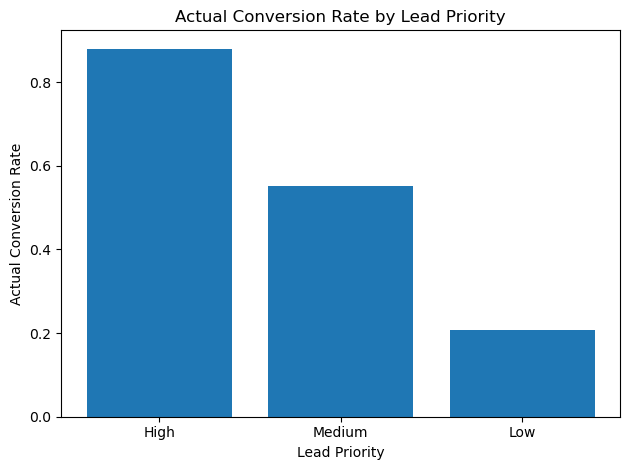

In [8]:
plt.bar(
    priority_summary["lead_priority"],
    priority_summary["actual_conversion_rate"]
)

plt.title("Actual Conversion Rate by Lead Priority")
plt.xlabel("Lead Priority")
plt.ylabel("Actual Conversion Rate")
plt.tight_layout()
plt.show()

## Sales Action Framework

The lead priority score can be used to guide sales team follow-up actions.

In [9]:
def recommend_action(priority):
    if priority == "High":
        return "Call within 1 hour, offer test drive, prepare personalised quote"
    elif priority == "Medium":
        return "Follow up within 24 hours, confirm vehicle interest, send finance or trade-in options"
    else:
        return "Add to nurture campaign, send promotional content, review again if engagement increases"

df["recommended_action"] = df["lead_priority"].apply(recommend_action)

df[[
    "lead_source",
    "vehicle_type",
    "new_or_used",
    "budget_range",
    "conversion_probability",
    "lead_priority",
    "recommended_action"
]].head(10)

,lead_source,vehicle_type,new_or_used,budget_range,conversion_probability,lead_priority,recommended_action
0,Walk-in,Ute,Used,Low,0.079043,Low,"Add to nurture campaign, send promotional cont..."
1,Carsales,Ute,Used,Medium,0.332412,Low,"Add to nurture campaign, send promotional cont..."
2,Walk-in,SUV,Demo,High,0.362910,Low,"Add to nurture campaign, send promotional cont..."
3,Walk-in,EV,Used,Low,0.228900,Low,"Add to nurture campaign, send promotional cont..."
4,Social Media,Hatchback,New,Medium,0.542355,Medium,"Follow up within 24 hours, confirm vehicle int..."
5,Website,Sedan,New,High,0.219406,Low,"Add to nurture campaign, send promotional cont..."
6,Website,SUV,Used,High,0.414249,Medium,"Follow up within 24 hours, confirm vehicle int..."
7,Walk-in,Ute,Used,Low,0.280921,Low,"Add to nurture campaign, send promotional cont..."
8,Carsales,SUV,Demo,Low,0.423676,Medium,"Follow up within 24 hours, confirm vehicle int..."
9,Social Media,SUV,Used,Medium,0.158191,Low,"Add to nurture campaign, send promotional cont..."


## Final Scored Lead Output

The final output is a scored lead list that a sales team could use to prioritise daily follow-up activity.

In [10]:
scored_leads = df.copy()

scored_leads = scored_leads.sort_values(
    by="conversion_probability",
    ascending=False
)

scored_leads.head(15)

,lead_source,customer_age_group,customer_location,vehicle_type,new_or_used,budget_range,finance_enquiry,trade_in,test_drive_completed,quote_provided,previous_customer,response_time_hours,follow_up_count,days_since_enquiry,actual_converted,predicted_converted,conversion_probability,lead_priority,recommended_action
115,Website,45-54,Far Suburb,SUV,New,High,1,1,1,1,1,5.4,7,8,1,1,0.948808,High,"Call within 1 hour, offer test drive, prepare ..."
241,Carsales,35-44,Nearby Suburb,SUV,Demo,Medium,1,1,1,1,1,7.0,4,6,1,1,0.883143,High,"Call within 1 hour, offer test drive, prepare ..."
42,Referral,25-34,Nearby Suburb,Ute,Used,Medium,1,0,1,1,1,4.3,5,10,1,1,0.871864,High,"Call within 1 hour, offer test drive, prepare ..."
143,Carsales,18-24,Far Suburb,Sedan,New,Medium,1,1,1,1,1,5.7,6,25,1,1,0.834425,High,"Call within 1 hour, offer test drive, prepare ..."
105,Walk-in,25-34,Far Suburb,EV,New,High,1,0,1,1,0,6.0,4,26,1,1,0.831455,High,"Call within 1 hour, offer test drive, prepare ..."
79,Walk-in,35-44,Local,Hatchback,New,High,1,0,1,1,0,5.1,2,18,1,1,0.827813,High,"Call within 1 hour, offer test drive, prepare ..."
371,Website,25-34,Nearby Suburb,EV,New,Low,1,1,1,1,1,7.7,4,16,1,1,0.805072,High,"Call within 1 hour, offer test drive, prepare ..."
100,Website,55+,Far Suburb,SUV,Used,Medium,0,1,1,1,1,4.3,1,8,1,1,0.802615,High,"Call within 1 hour, offer test drive, prepare ..."
85,Walk-in,18-24,Local,Hatchback,Used,Medium,0,1,1,1,1,13.8,3,6,1,1,0.797773,High,"Call within 1 hour, offer test drive, prepare ..."
32,Walk-in,25-34,Nearby Suburb,SUV,New,Low,1,1,1,1,1,18.7,0,3,1,1,0.793719,High,"Call within 1 hour, offer test drive, prepare ..."


In [11]:
output_path = "../data/processed/scored_leads.csv"

scored_leads.to_csv(output_path, index=False)

print(f"Scored leads saved to: {output_path}")

Scored leads saved to: ../data/processed/scored_leads.csv


## Lead Source Opportunity Analysis

This analysis helps identify which channels produce the strongest high-priority leads.

In [12]:
source_priority = (
    df.groupby(["lead_source", "lead_priority"])
    .size()
    .reset_index(name="lead_count")
)

source_priority

,lead_source,lead_priority,lead_count
0,Carsales,High,3
1,Carsales,Low,65
2,Carsales,Medium,17
3,Phone,High,2
4,Phone,Low,31
5,Phone,Medium,18
6,Referral,High,5
7,Referral,Low,21
8,Referral,Medium,10
9,Social Media,Low,28


In [13]:
high_priority_by_source = (
    df[df["lead_priority"] == "High"]
    .groupby("lead_source")
    .size()
    .sort_values(ascending=False)
)

high_priority_by_source

lead_source
Walk-in     9
Website     6
Referral    5
Carsales    3
Phone       2
dtype: int64

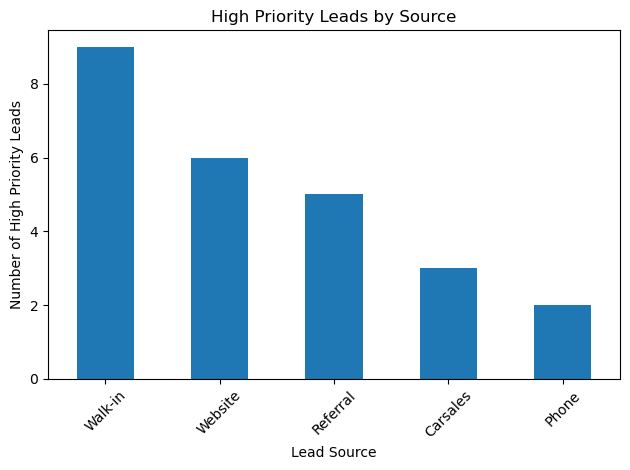

In [14]:
high_priority_by_source.plot(kind="bar")

plt.title("High Priority Leads by Source")
plt.xlabel("Lead Source")
plt.ylabel("Number of High Priority Leads")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Business Recommendations

Based on the lead scoring analysis:

1. Prioritise high-probability leads for immediate salesperson follow-up.
2. Treat test drive, finance enquiry, quote request and trade-in interest as strong buying-intent signals.
3. Use medium-priority leads for structured follow-up campaigns within 24 hours.
4. Move low-priority leads into longer-term nurture campaigns instead of using heavy sales effort immediately.
5. Review lead source quality regularly, as some channels may generate high volume but lower conversion potential.

This framework helps dealership sales teams focus time on the leads most likely to generate revenue while still maintaining a structured process for lower-intent prospects.